# Supplementary Figure S6: Sensitivity Analysis
Replicate concordance and effect-size vs. significance analysis for AD GWAS spatial enrichment.

In [1]:
%matplotlib inline
import omicverse as ov
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr

LEGEND_FS = 11; TICK_FS = 12; LABEL_FS = 13; TITLE_FS = 13; TEXT_FS = 12

def save_all_formats(fig, basepath, dpi=300):
    fig.savefig(f"{basepath}.pdf", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.png", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.svg", bbox_inches="tight")

BASE = '../analysis/26_gsmap'
os.makedirs(f'{BASE}/figures', exist_ok=True)

## Load all results

In [3]:
available_samples = sorted([d for d in os.listdir(f'{BASE}/models/gsmap_output/')
                            if os.path.isdir(f'{BASE}/models/gsmap_output/{d}')])

# Load spot-level results
spot_dfs = []
for sname in available_samples:
    fpath = f'{BASE}/models/gsmap_output/{sname}/spatial_ldsc/{sname}_AD.csv.gz'
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        df['sample_name'] = sname
        organ = sname.rsplit('_', 1)[0].replace('_', ' ')
        replicate = 'CTRL1' if 'CTRL1' in sname else 'CTRL2'
        df['organ'] = organ
        df['replicate'] = replicate
        df['logp'] = -np.log10(df['p'].clip(lower=1e-300))
        spot_dfs.append(df)
spot_all = pd.concat(spot_dfs, ignore_index=True)

# Load Cauchy results
cauchy_dfs = []
for sname in available_samples:
    fpath = f'{BASE}/models/gsmap_output/{sname}/cauchy_combination/{sname}_AD.Cauchy.csv.gz'
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        df['sample_name'] = sname
        organ = sname.rsplit('_', 1)[0].replace('_', ' ')
        replicate = 'CTRL1' if 'CTRL1' in sname else 'CTRL2'
        df['organ'] = organ
        df['replicate'] = replicate
        df['logp_cauchy'] = -np.log10(df['p_cauchy'].clip(lower=1e-300))
        cauchy_dfs.append(df)
cauchy_all = pd.concat(cauchy_dfs, ignore_index=True)

print(f'Spot results: {len(spot_all)} spots from {spot_all["sample_name"].nunique()} samples')
print(f'Cauchy results: {len(cauchy_all)} annotations from {cauchy_all["sample_name"].nunique()} samples')

Spot results: 1120354 spots from 32 samples
Cauchy results: 86 annotations from 32 samples


## Panel A: CTRL1 vs CTRL2 organ-level results (side-by-side bar plot)

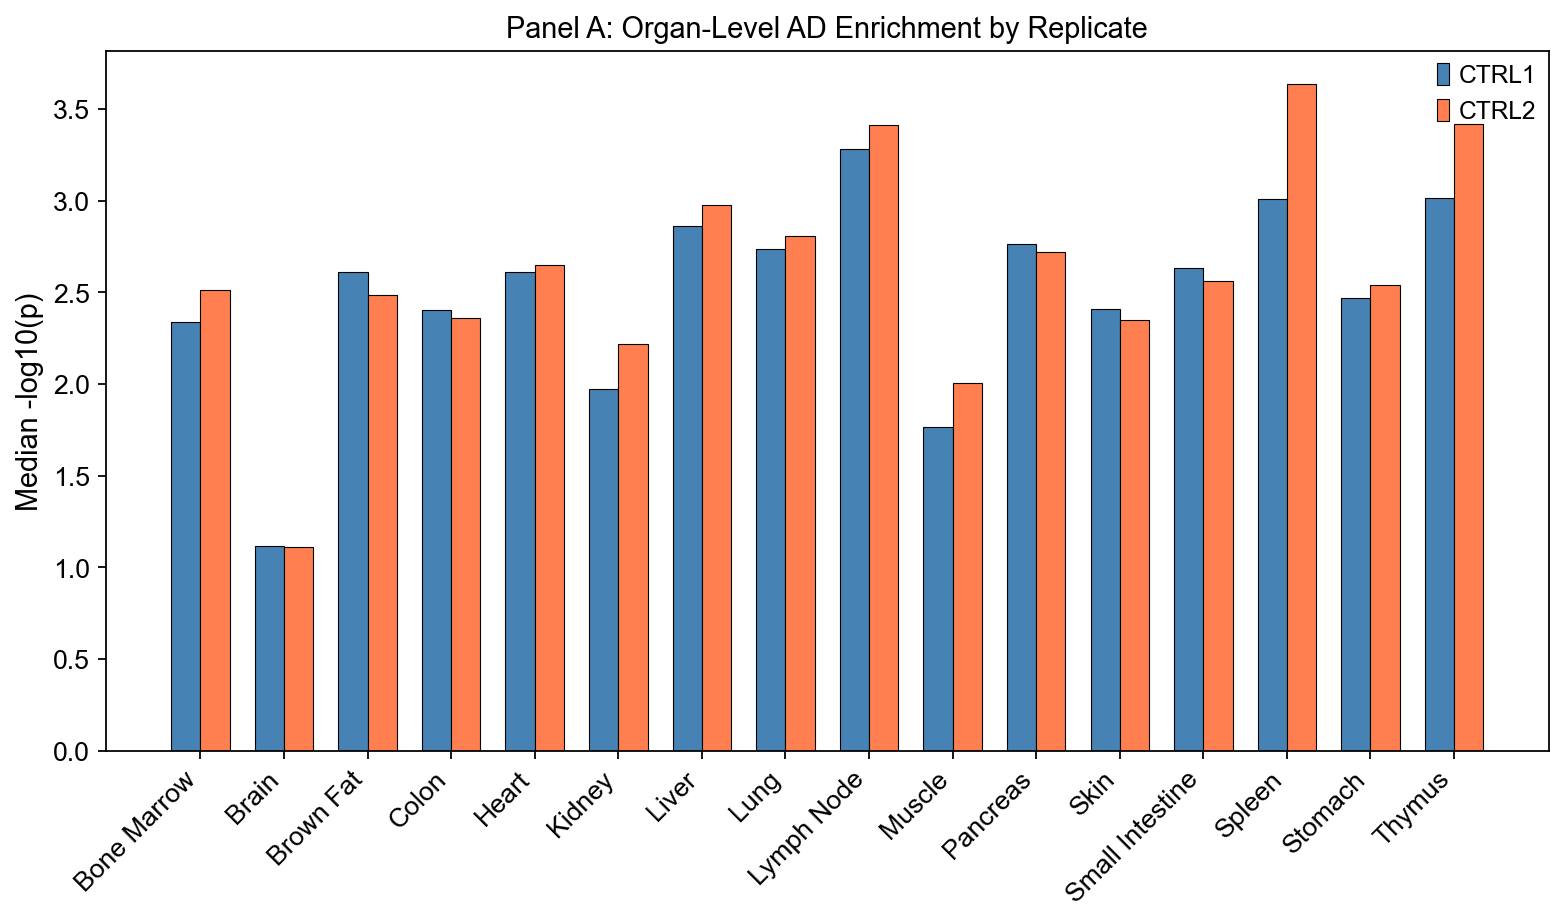

In [4]:
# Compute organ-level median -log10(p) for each replicate
organ_summary = spot_all.groupby(['organ', 'replicate'])['logp'].median().reset_index()
organ_summary_pivot = organ_summary.pivot(index='organ', columns='replicate', values='logp').fillna(0)

organs_sorted = organ_summary_pivot.index.tolist()
x = np.arange(len(organs_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
if 'CTRL1' in organ_summary_pivot.columns:
    ax.bar(x - width/2, organ_summary_pivot.get('CTRL1', 0), width, label='CTRL1', color='steelblue', edgecolor='k', linewidth=0.5)
if 'CTRL2' in organ_summary_pivot.columns:
    ax.bar(x + width/2, organ_summary_pivot.get('CTRL2', 0), width, label='CTRL2', color='coral', edgecolor='k', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(organs_sorted, rotation=45, ha='right', fontsize=TICK_FS)
ax.set_ylabel('Median -log10(p)', fontsize=LABEL_FS)
ax.set_title('Panel A: Organ-Level AD Enrichment by Replicate', fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS)
ax.tick_params(axis='y', labelsize=TICK_FS)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S06A_replicate_barplot')

## Panel B: Scatter of CTRL1 vs CTRL2 Cauchy p-values per annotation

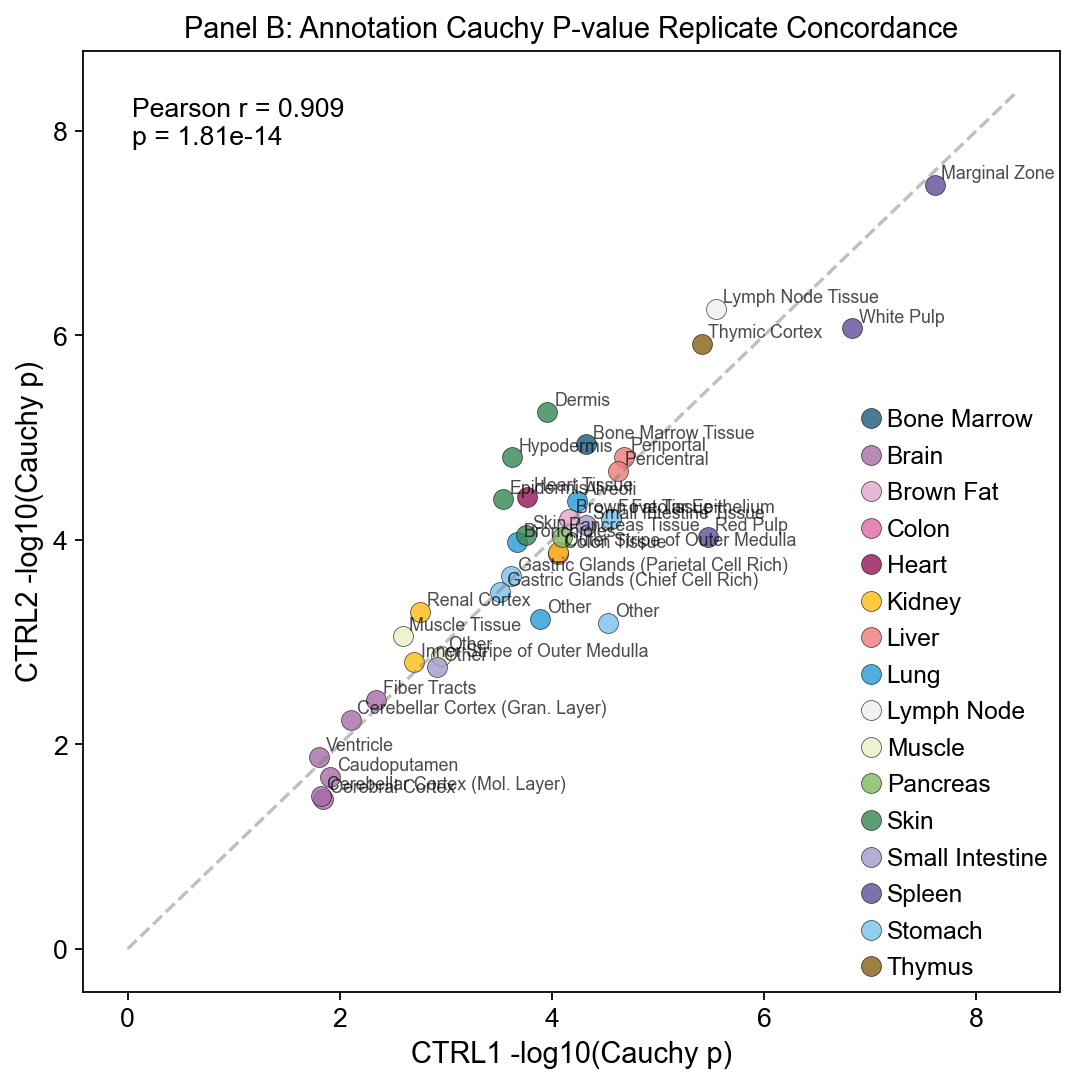

In [5]:
organs_both = set(cauchy_all[cauchy_all['replicate'] == 'CTRL1']['organ']) & \
              set(cauchy_all[cauchy_all['replicate'] == 'CTRL2']['organ'])

if len(organs_both) > 0:
    ctrl1_c = cauchy_all[cauchy_all['replicate'] == 'CTRL1'][['organ', 'annotation', 'logp_cauchy']]
    ctrl2_c = cauchy_all[cauchy_all['replicate'] == 'CTRL2'][['organ', 'annotation', 'logp_cauchy']]
    merged_c = ctrl1_c.merge(ctrl2_c, on=['organ', 'annotation'], suffixes=('_CTRL1', '_CTRL2'))
    
    fig, ax = plt.subplots(figsize=(7, 7))
    colors_map = plt.cm.Set2(np.linspace(0, 1, len(organs_both)))
    for i, organ in enumerate(sorted(organs_both)):
        sub = merged_c[merged_c['organ'] == organ]
        ax.scatter(sub['logp_cauchy_CTRL1'], sub['logp_cauchy_CTRL2'],
                   s=80, label=organ, alpha=0.8, edgecolors='k', linewidths=0.3)
        for _, row in sub.iterrows():
            ax.annotate(row['annotation'], (row['logp_cauchy_CTRL1'], row['logp_cauchy_CTRL2']),
                       fontsize=LEGEND_FS - 3, alpha=0.7, xytext=(3, 3), textcoords='offset points')
    
    if len(merged_c) >= 3:
        r, pval = pearsonr(merged_c['logp_cauchy_CTRL1'], merged_c['logp_cauchy_CTRL2'])
        ax.text(0.05, 0.95, f'Pearson r = {r:.3f}\np = {pval:.2e}',
                transform=ax.transAxes, fontsize=TEXT_FS, va='top')
    
    maxv = max(merged_c[['logp_cauchy_CTRL1', 'logp_cauchy_CTRL2']].max().max(), 1) * 1.1
    ax.plot([0, maxv], [0, maxv], '--', color='grey', alpha=0.5)
    ax.set_xlabel('CTRL1 -log10(Cauchy p)', fontsize=LABEL_FS)
    ax.set_ylabel('CTRL2 -log10(Cauchy p)', fontsize=LABEL_FS)
    ax.set_title('Panel B: Annotation Cauchy P-value Replicate Concordance', fontsize=TITLE_FS)
    ax.legend(fontsize=LEGEND_FS)
    ax.tick_params(labelsize=TICK_FS)
    fig.tight_layout()
    save_all_formats(fig, f'{BASE}/figures/S06B_cauchy_replicate_scatter')
else:
    print('Not enough replicate pairs available yet.')

## Panel C: Volcano-like plot: effect size (median logp) vs significance (-log10 Cauchy p)

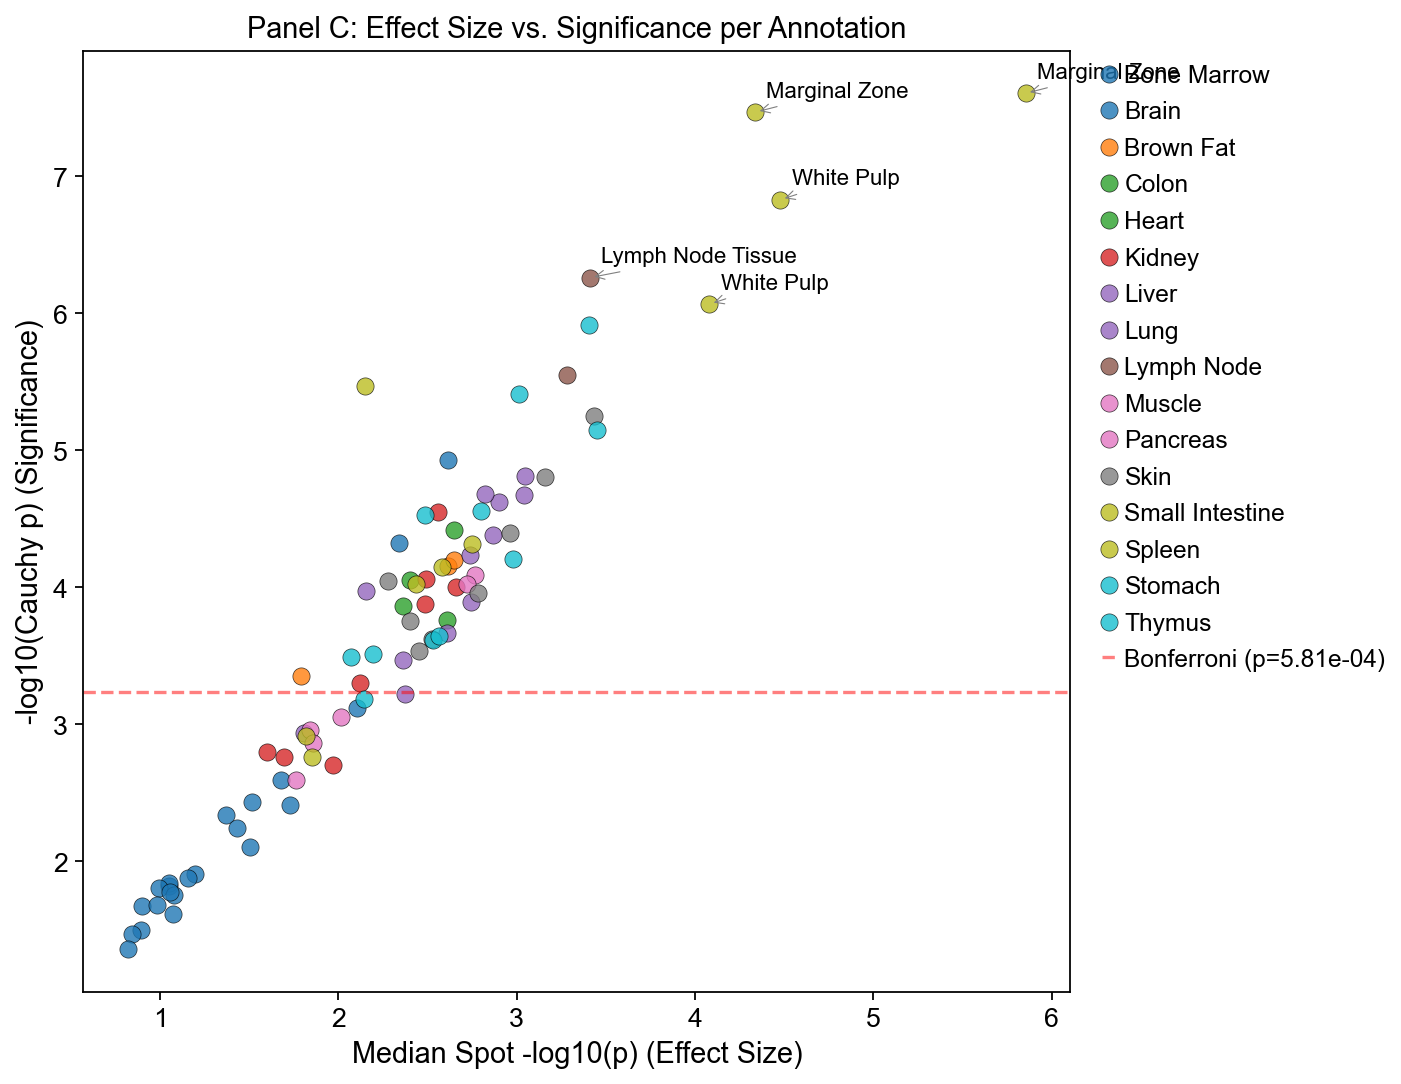

In [6]:
# For each annotation, compute median spot-level logp as effect size
# and Cauchy p as significance
# Need to match annotations to spots via organ+annotation

# Get annotation-level median logp from spots
# Load per-organ h5ad to get annotation per spot
import anndata as ad

effect_data = []
for sname in available_samples:
    pval_path = f'{BASE}/models/gsmap_output/{sname}/spatial_ldsc/{sname}_AD.csv.gz'
    cauchy_path = f'{BASE}/models/gsmap_output/{sname}/cauchy_combination/{sname}_AD.Cauchy.csv.gz'
    organ_file = f'{BASE}/data/st/per_organ/{sname}.h5ad'
    
    if not (os.path.exists(pval_path) and os.path.exists(cauchy_path) and os.path.exists(organ_file)):
        continue
    
    pvals = pd.read_csv(pval_path)
    cauchy = pd.read_csv(cauchy_path)
    adata_org = ad.read_h5ad(organ_file, backed='r')
    
    # Get annotation per spot
    annot = adata_org.obs[['annotation']].copy()
    annot.index.name = 'spot'
    annot = annot.reset_index()
    annot.rename(columns={'index': 'spot'}, inplace=True)
    
    merged = pvals.merge(annot, on='spot', how='inner')
    merged['logp'] = -np.log10(merged['p'].clip(lower=1e-300))
    
    # Median logp per annotation
    annot_median = merged.groupby('annotation')['logp'].median().reset_index()
    annot_median.columns = ['annotation', 'median_logp']
    
    # Merge with Cauchy
    annot_full = annot_median.merge(cauchy[['annotation', 'p_cauchy']], on='annotation', how='inner')
    annot_full['logp_cauchy'] = -np.log10(annot_full['p_cauchy'].clip(lower=1e-300))
    annot_full['sample_name'] = sname
    annot_full['organ'] = sname.rsplit('_', 1)[0].replace('_', ' ')
    effect_data.append(annot_full)
    del adata_org

effect_df = pd.concat(effect_data, ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_map = plt.cm.tab10(np.linspace(0, 1, effect_df['organ'].nunique()))
organs_unique = sorted(effect_df['organ'].unique())

for i, organ in enumerate(organs_unique):
    sub = effect_df[effect_df['organ'] == organ]
    ax.scatter(sub['median_logp'], sub['logp_cauchy'],
              s=60, label=organ, alpha=0.8, color=colors_map[i], edgecolors='k', linewidths=0.3)

# Significance threshold
sig_thresh = -np.log10(0.05 / len(effect_df))
ax.axhline(sig_thresh, color='red', linestyle='--', alpha=0.5, label=f'Bonferroni (p={0.05/len(effect_df):.2e})')

ax.set_xlabel('Median Spot -log10(p) (Effect Size)', fontsize=LABEL_FS)
ax.set_ylabel('-log10(Cauchy p) (Significance)', fontsize=LABEL_FS)
ax.set_title('Panel C: Effect Size vs. Significance per Annotation', fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(labelsize=TICK_FS)

# Label top points
top_annots = effect_df.nlargest(5, 'logp_cauchy')
for _, row in top_annots.iterrows():
    ax.annotate(row['annotation'], (row['median_logp'], row['logp_cauchy']),
               fontsize=TEXT_FS - 2, ha='left', va='bottom', xytext=(5, 5), textcoords='offset points',
               arrowprops=dict(arrowstyle='->', color='grey', lw=0.5))

fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S06C_volcano_annotation')